# EDA of the encoder input (T = 64, every window padded to 64 + mask)

This notebook looks at the windows the encoder will read, in `src/data/encoder_input/benign_gridsybil/T64/` (built by
`src/pipeline/benign_gridsybil/encoder_input_T64.ipynb`). Each window holds up to 64 real messages × 13 features and
is padded to 64 rows, with a mask (1 = real message, 0 = padding). Values are already normalised (z-scores fitted on
the real rows of train).

The data has two splits, **train** and **test** (90 / 10 by sender vehicle, seed 0, stratified by scenario group ×
class). Pretraining is self-supervised, reads train only, and keeps 10% of the train sender vehicles as a label-free
check set (previewed at the end). The splits are discovered from the folders, so the notebook also runs on other
layouts.

Labels are read from the `_info` files **for analysis only**. Every probe and single-feature AUC is **fitted on train
and evaluated on test**. Each analysis prints one line starting with `Observation:`; the numbers in it are computed,
not written by hand. Nothing is written to disk.

In [1]:
import importlib.util
import json
import multiprocessing
import os
import pathlib
import sys
import time
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

for _folder in [
    pathlib.Path.cwd(),
    *pathlib.Path.cwd().parents,
]:  # notebooks live in src/<folder>/; work from the repo root
    if (_folder / "CLAUDE.md").is_file():
        os.chdir(_folder)
        break
assert pathlib.Path("CLAUDE.md").is_file() and pathlib.Path("data").is_dir(), "run from the repo root"

ROOT = pathlib.Path("src/data/encoder_input/benign_gridsybil/T64")
META = json.loads((ROOT / "metadata.json").read_text())
FEATURES: list[str] = META["features"]
_ORDER = ["train", "pretrain_val", "val", "test"]
SPLITS = sorted(
    (p.name for p in ROOT.iterdir() if p.is_dir()), key=lambda s: (_ORDER.index(s) if s in _ORDER else 99, s)
)
FIT, EVAL = "train", SPLITS[-1]  # probes are fitted on train and evaluated on the last split (test)
assert FIT in SPLITS and EVAL != FIT, f"need train and one more split, found {SPLITS}"
COLOURS = {"Benign": "#16A34A", "GridSybil": "#BE185D"}
SPLIT_STYLE = {s: ls for s, ls in zip(SPLITS, ["-", "--", ":", "-."])}
pd.set_option("display.width", 160)
print(
    f"{len(FEATURES)} features; window length {META['max_seq_len']}; overall padding {META['padding']['overall']:.1%}; "
    f"splits {SPLITS}; probes fit on {FIT!r}, evaluated on {EVAL!r}"
)

13 features; window length 64; overall padding 71.0%; splits ['train', 'test']; probes fit on 'train', evaluated on 'test'


## Load every shard

`EncoderInputLoader` reads the shards in parallel. Every window is 64 rows, so there is one array of shape
(windows, 64, 13) plus a (windows, 64) mask; the loader groups by the folder name (`b64`), so it would also read a
bucketed variant. `info` holds one row per window (split, label, number of real messages, sender, receiver, scenario).
`vehicle` is the sender vehicle key used by the split and by pretraining's check set (`<group>:<sender>`, same rule as
`FeatureShards.vehicle_of`).

In [2]:
def _read_shard(path: str) -> tuple[str, str, np.ndarray, np.ndarray, list[dict[str, Any]]]:
    """Reads one shard and its info file (top-level so the process pool can call it)."""
    p = pathlib.Path(path)
    data = json.loads(p.read_text())
    info = json.loads(p.with_name(p.stem + "_info.json").read_text())["windows"]
    x = np.asarray([w["x"] for w in data["windows"]], dtype=np.float32)
    mask = np.asarray([w["mask"] for w in data["windows"]], dtype=np.uint8)
    return p.parts[-3], p.parts[-2], x, mask, info


def vehicle_of(window_id: str) -> str:
    """`<scenario>/<run>/<file>#<pseudo>-<sender>#<k>` -> `"<group>:<sender>"` (as FeatureShards.vehicle_of)."""
    scenario = window_id.split("/", 1)[0]
    sender = window_id.rsplit("#", 2)[1].split("-")[-1]
    return f"{scenario.rsplit('_', 1)[1]}:{sender}"


class EncoderInputLoader:
    """Loads the sharded encoder input into one (x, mask) pair per bucket plus a window table."""

    def __init__(self, root: pathlib.Path, workers: int = 8) -> None:
        self.root = root
        self.workers = workers

    def load(self) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray], pd.DataFrame]:
        """Returns (x by bucket, mask by bucket, info table with a row index into its bucket)."""
        paths = sorted(str(p) for p in self.root.glob("*/b*/part-?????.json"))
        with multiprocessing.get_context("fork").Pool(self.workers) as pool:
            parts = pool.map(_read_shard, paths)
        xs: dict[int, list] = {}
        ms: dict[int, list] = {}
        rows: list[dict[str, Any]] = []
        for split, bucket_dir, x, mask, info in parts:
            bucket = int(bucket_dir[1:])
            offset = sum(len(a) for a in xs.get(bucket, []))
            xs.setdefault(bucket, []).append(x)
            ms.setdefault(bucket, []).append(mask)
            for k, r in enumerate(info):
                rows.append({**r, "split": split, "bucket": bucket, "row": offset + k})
        x_by = {b: np.concatenate(v) for b, v in xs.items()}
        m_by = {b: np.concatenate(v) for b, v in ms.items()}
        table = pd.DataFrame(rows)
        table["group"] = table["scenario"].str.rsplit("_", n=1).str[1]
        table["vehicle"] = table["id"].map(vehicle_of)
        return x_by, m_by, table


_t = time.perf_counter()
X, MASK, info = EncoderInputLoader(ROOT).load()
print(
    f"loaded {len(info):,} windows in {time.perf_counter() - _t:.1f} s; "
    f"buckets: {{{', '.join(f'{b}: {len(X[b]):,}' for b in sorted(X))}}}"
)

loaded 376,427 windows in 6.7 s; buckets: {64: 376,427}


## Counts and padding

How many windows and sender vehicles each split and class has, and how much of the stored rows is padding. Padding
share = padding rows ÷ all rows (every window stores 64 rows). The vehicle overlap between splits must be 0: the split
is by sender vehicle. Vehicles are counted from the windows; the split manifest counts every labelled vehicle in
`index.json`, including a few that send no kept window, so its totals can be slightly higher.

In [3]:
stored = info["bucket"].astype(int)
info["padding_rows"] = stored - info["n_messages"]
counts = info.groupby(["split", "label_name"]).agg(
    windows=("id", "size"),
    vehicles=("vehicle", "nunique"),
    real_rows=("n_messages", "sum"),
    padding_rows=("padding_rows", "sum"),
)
counts["padding_share"] = (counts["padding_rows"] / (counts["real_rows"] + counts["padding_rows"])).round(3)
counts = counts.reindex(SPLITS, level=0)
print(counts.to_string())
vehicles = {s: set(info.loc[info["split"] == s, "vehicle"]) for s in SPLITS}
overlap = {f"{a}&{b}": len(vehicles[a] & vehicles[b]) for i, a in enumerate(SPLITS) for b in SPLITS[i + 1 :]}
print("\nsender vehicles per split:", {s: len(v) for s, v in vehicles.items()}, "| overlap:", overlap)
total_rows = int(stored.sum())
overall_pad = 1 - info["n_messages"].sum() / total_rows
_sums = info.groupby("split")[["n_messages", "bucket"]].sum().reindex(SPLITS)
pad_split = 1 - _sums["n_messages"] / _sums["bucket"]
print(
    "Observation: "
    + "; ".join(
        f"{s} {int((info['split'] == s).sum()):,} windows / {len(vehicles[s]):,} vehicles / padding {pad_split[s]:.1%}"
        for s in SPLITS
    )
    + f"; vehicle overlap between splits = {sum(overlap.values())}; overall padding {overall_pad:.1%} of "
    f"{total_rows:,} stored rows."
)

                  windows  vehicles  real_rows  padding_rows  padding_share
split label_name                                                           
train Benign       120073      3625    2367693       5316979          0.692
      GridSybil    217928      1553    3886461      10060931          0.721
test  Benign        12741       401     248250        567174          0.696
      GridSybil     25685       173     477952       1165888          0.709

sender vehicles per split: {'train': 5178, 'test': 574} | overlap: {'train&test': 0}
Observation: train 338,001 windows / 5,178 vehicles / padding 71.1%; test 38,426 windows / 574 vehicles / padding 70.5%; vehicle overlap between splits = 0; overall padding 71.0% of 24,091,328 stored rows.


**Researcher note:** [RISK] Vehicle-disjoint (0 overlap), but there is no labelled validation split: probes and Stage 2 K, θ need a vehicle-grouped carve from train; also reconcile 5,178 / 574 with the 5,180 / 575 in the split manifest.

## Class balance and length per split

Benign share and the share of very short windows (1–3 real messages) for every split and class. If train and test
differed here, a test number would partly measure the mix rather than the model.

In [4]:
balance = info.groupby(["split", "label_name"]).agg(
    windows=("id", "size"),
    median_len=("n_messages", "median"),
    mean_len=("n_messages", "mean"),
    share_1_to_3=("n_messages", lambda n: (n <= 3).mean()),
    share_full_64=("n_messages", lambda n: (n == 64).mean()),
)
balance["share_of_split"] = balance["windows"] / balance.groupby(level="split")["windows"].transform("sum")
balance = balance.reindex(SPLITS, level=0).round(3)
print(balance.to_string())
benign_share = info.groupby("split")["label_name"].apply(lambda s: s.eq("Benign").mean()).reindex(SPLITS)
print(
    "Observation: benign share "
    + " / ".join(f"{s} {benign_share[s]:.1%}" for s in SPLITS)
    + "; 1–3-message windows "
    + "; ".join(f"{c} " + " / ".join(f"{s} {balance.loc[(s, c), 'share_1_to_3']:.1%}" for s in SPLITS) for c in COLOURS)
    + "; median length "
    + "; ".join(f"{c} " + " / ".join(f"{s} {balance.loc[(s, c), 'median_len']:.0f}" for s in SPLITS) for c in COLOURS)
    + "."
)

                  windows  median_len  mean_len  share_1_to_3  share_full_64  share_of_split
split label_name                                                                            
train Benign       120073        15.0    19.719         0.139          0.056           0.355
      GridSybil    217928        11.0    17.834         0.203          0.063           0.645
test  Benign        12741        14.0    19.484         0.143          0.057           0.332
      GridSybil     25685        12.0    18.608         0.191          0.071           0.668
Observation: benign share train 35.5% / test 33.2%; 1–3-message windows Benign train 13.9% / test 14.3%; GridSybil train 20.3% / test 19.1%; median length Benign train 15 / test 14; GridSybil train 11 / test 12.


**Researcher note:** [RISK] Balance is stable (benign 35.5% vs 33.2%), but 1–3-message windows (benign 14%, GridSybil 19–20%) are below min_rows_aux = 4, so they get reconstruction only; report probes per length band.

## Scenario-group mix per split

Share of windows from the 0709 and the 1416 scenario group, per split and class. The split was stratified by group ×
class, so the shares should match between splits. Time of day separates the two groups, so an uneven mix would be a
confound.

In [5]:
mix = pd.crosstab([info["split"], info["label_name"]], info["group"], normalize="index").reindex(SPLITS, level=0)
mix_n = pd.crosstab([info["split"], info["label_name"]], info["group"]).reindex(SPLITS, level=0)
print(mix.round(3).to_string())
print()
print(mix_n.to_string())
g0 = sorted(info["group"].unique())[0]
gap = (mix[g0].unstack("label_name").max() - mix[g0].unstack("label_name").min()).max()
print(
    f"Observation: {g0} share "
    + "; ".join(f"{c} " + " / ".join(f"{s} {mix.loc[(s, c), g0]:.1%}" for s in SPLITS) for c in COLOURS)
    + f"; largest gap between splits within a class = {gap * 100:.1f} percentage points."
)

group              0709   1416
split label_name              
train Benign      0.822  0.178
      GridSybil   0.799  0.201
test  Benign      0.809  0.191
      GridSybil   0.838  0.162

group               0709   1416
split label_name               
train Benign       98685  21388
      GridSybil   174185  43743
test  Benign       10308   2433
      GridSybil    21527   4158
Observation: 0709 share Benign train 82.2% / test 80.9%; GridSybil train 79.9% / test 83.8%; largest gap between splits within a class = 3.9 percentage points.


**Researcher note:** [RISK] Mix matches within 3.9 pp, but 1416 test is only 6,591 windows (2,433 benign / 4,158 GridSybil); 0709 ↔ 1416 transfer numbers need vehicle-level bootstrap CIs.

## Ghost pseudonym 1 (F13)

In every GridSybil run the ghost messages share pseudonym 1. A model that sees the pseudonym (it does not: the
pseudonym is not one of the 13 features) or a grouping that uses it would get the label for free. Here: the share of
GridSybil windows whose sender pseudonym is 1, per split, and whether any benign window has it.

In [6]:
info["pseudo_is_1"] = info["sender_pseudo"].astype(np.int64).eq(1)
ghost = info.groupby(["split", "label_name"])["pseudo_is_1"].agg(["mean", "sum"]).reindex(SPLITS, level=0)
print(ghost.round(3).to_string())
ghost_vehicles = info[info["pseudo_is_1"]].groupby("split")["vehicle"].nunique().reindex(SPLITS)
print("sender vehicles behind pseudonym 1 per split:", ghost_vehicles.to_dict())
print(
    "Observation: GridSybil windows with sender pseudonym 1: "
    + " / ".join(f"{s} {ghost.loc[(s, 'GridSybil'), 'mean']:.1%}" for s in SPLITS)
    + f"; benign windows with pseudonym 1: {int(info.loc[info['label_name'] == 'Benign', 'pseudo_is_1'].sum())}."
)

                   mean    sum
split label_name              
train Benign      0.000      0
      GridSybil   0.204  44406
test  Benign      0.000      0
      GridSybil   0.215   5524
sender vehicles behind pseudonym 1 per split: {'train': 1504, 'test': 168}
Observation: GridSybil windows with sender pseudonym 1: train 20.4% / test 21.5%; benign windows with pseudonym 1: 0.


**Researcher note:** [RISK] 20.4% / 21.5% of GridSybil windows carry pseudonym 1, from 1,504 of 1,553 train GridSybil vehicles; exclude pseudonym 1 from D6's 'other pseudonym' rule and never use the true-sender key in pretraining.

## Window length and the length shortcut

`n_messages` = real messages in a window. If one class has many more short windows, a model could use length as a
clue instead of the motion (a shortcut). The probe below fits a logistic regression on **length only**, **fitted on
train and evaluated on test**; an AUC near 0.5 means length says little about the class.

                     count    mean  25%   50%   75%   90%   max
split label_name                                               
train Benign      120073.0  19.719  7.0  15.0  27.0  48.0  64.0
      GridSybil   217928.0  17.834  4.0  11.0  24.0  48.0  64.0
test  Benign       12741.0  19.484  6.0  14.0  27.0  47.0  64.0
      GridSybil    25685.0  18.608  5.0  12.0  26.0  52.0  64.0


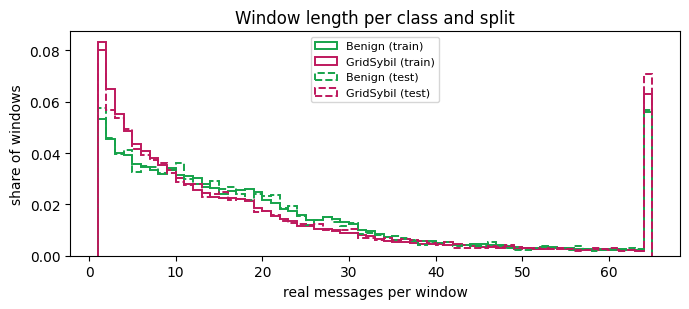

Observation: length-only probe (fit on train, evaluated on test) AUC = 0.535 (0.5 = chance).


In [7]:
class LengthReport:
    """Window-length distribution per split and class and a length-only probe."""

    def __init__(self, table: pd.DataFrame) -> None:
        self.table = table

    def summary(self) -> pd.DataFrame:
        """Length statistics per split and class."""
        g = self.table.groupby(["split", "label_name"])["n_messages"]
        out = g.describe(percentiles=[0.25, 0.5, 0.75, 0.9])[["count", "mean", "25%", "50%", "75%", "90%", "max"]]
        return out.reindex(SPLITS, level=0).round(3)

    def probe_auc(self, fit: str = FIT, evaluate: str = EVAL) -> float:
        """AUC on `evaluate` of a logistic regression fitted on `fit` that sees only the number of real messages."""
        tr = self.table[self.table["split"] == fit]
        ev = self.table[self.table["split"] == evaluate]
        model = LogisticRegression(class_weight="balanced").fit(tr[["n_messages"]], tr["is_attack"])
        return float(roc_auc_score(ev["is_attack"], model.predict_proba(ev[["n_messages"]])[:, 1]))


length = LengthReport(info)
print(length.summary().to_string())
auc_len = length.probe_auc()
fig, ax = plt.subplots(figsize=(7, 3.2))
for split in SPLITS:
    for name, colour in COLOURS.items():
        n = info.loc[(info["label_name"] == name) & (info["split"] == split), "n_messages"]
        ax.hist(
            n,
            bins=np.arange(1, 66),
            density=True,
            histtype="step",
            lw=1.4,
            ls=SPLIT_STYLE[split],
            color=colour,
            label=f"{name} ({split})",
        )
ax.set_xlabel("real messages per window")
ax.set_ylabel("share of windows")
ax.legend(fontsize=8)
ax.set_title("Window length per class and split")
plt.tight_layout()
plt.show()
print(f"Observation: length-only probe (fit on {FIT}, evaluated on {EVAL}) AUC = {auc_len:.3f} (0.5 = chance).")

**Researcher note:** [RIGHT] Length alone gives test AUC 0.535, a weak shortcut; report it next to every probe as the floor a learned encoder must clearly beat.

## Padding and why the mask matters

Left: the share of windows that still have a real message at each of the 64 positions, per class (solid = train,
dashed = test). Real rows are always at the start, so the curve only falls; where it is low, almost every value the
encoder sees is padding. Right: padding share per window.

The table shows what happens if the encoder **ignores the mask** and averages all 64 rows. The padding zeros pull the
average towards 0 by an amount that depends only on the window length, so the plain average quietly encodes length.
For each feature a one-feature logistic regression is **fitted on train** on the plain average and on the masked
average (real rows only) and **evaluated on test** (AUC). A gap between the two is information that comes from
padding, not from motion.

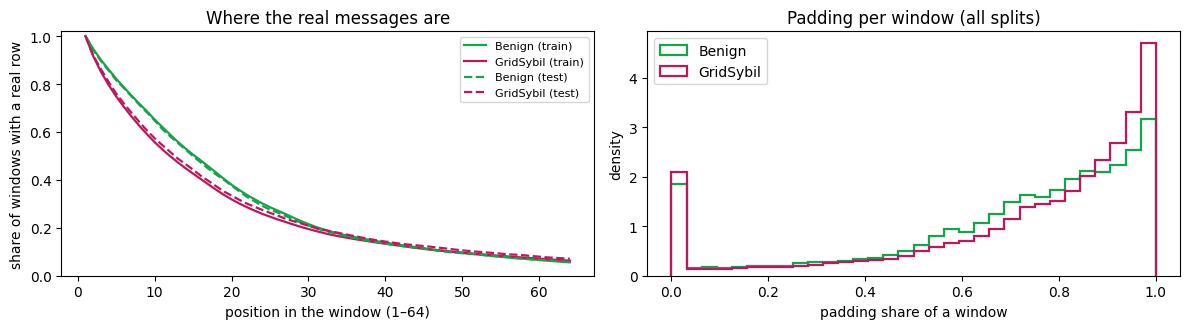

               plain_mean_auc  masked_mean_auc    gap
log_dtau                0.562            0.507  0.055
range                   0.540            0.513  0.027
rx_pos_y                0.460            0.465  0.005
claimed_pos_x           0.491            0.496  0.005
rx_vel_x                0.488            0.493  0.005
claimed_pos_y           0.452            0.456  0.003
claimed_acl_x           0.486            0.512  0.002
rx_pos_x                0.488            0.490  0.002
claimed_vel_x           0.465            0.465  0.000
claimed_acl_y           0.500            0.504 -0.004
bearing                 0.500            0.492 -0.008
rx_vel_y                0.503            0.512 -0.008
claimed_vel_y           0.457            0.446 -0.012
Observation: half of the windows are padding from position train benign 16 / GridSybil 12; test benign 15 / GridSybil 13; at position 64, train 5.6% benign / 6.3% GridSybil windows are real. Ignoring the mask moves the best single-feature test 

In [8]:
def window_means(x_by: dict[int, np.ndarray], m_by: dict[int, np.ndarray], table: pd.DataFrame, split: str):
    """Plain (all 64 rows) and masked (real rows) per-window means plus attack labels, for one split."""
    plain, masked, labels = [], [], []
    for b, x in x_by.items():
        sel = table[(table["bucket"] == b) & (table["split"] == split)]
        idx = sel["row"].to_numpy()
        m = m_by[b][idx].astype(np.float32)[..., None]
        plain.append(x[idx].mean(1))
        masked.append((x[idx] * m).sum(1) / m.sum(1))
        labels.append(sel["is_attack"].to_numpy())
    return np.concatenate(plain), np.concatenate(masked), np.concatenate(labels)


def fitted_auc(train_x: np.ndarray, train_y: np.ndarray, eval_x: np.ndarray, eval_y: np.ndarray) -> float:
    """Test AUC of a one-feature logistic regression fitted on train (train fixes the direction)."""
    model = LogisticRegression(class_weight="balanced").fit(train_x[:, None], train_y)
    return float(roc_auc_score(eval_y, model.predict_proba(eval_x[:, None])[:, 1]))


class PaddingReport:
    """How padding is spread over positions and what an unmasked average would leak."""

    def __init__(self, x_by: dict[int, np.ndarray], m_by: dict[int, np.ndarray], table: pd.DataFrame) -> None:
        self.x_by, self.m_by, self.table = x_by, m_by, table

    def real_share_by_position(self, label: str, split: str | None = None) -> np.ndarray:
        """Share of the class's windows with a real row at each position (64 values)."""
        sel = self.table[self.table["label_name"] == label]
        if split is not None:
            sel = sel[sel["split"] == split]
        return np.concatenate([self.m_by[b][sel.loc[sel["bucket"] == b, "row"].to_numpy()] for b in self.m_by]).mean(
            axis=0
        )

    def masked_vs_plain_auc(self, fit: str = FIT, evaluate: str = EVAL) -> pd.DataFrame:
        """Per feature: AUC on `evaluate` of the plain and the masked window mean, each fitted on `fit`."""
        p_tr, m_tr, y_tr = window_means(self.x_by, self.m_by, self.table, fit)
        p_ev, m_ev, y_ev = window_means(self.x_by, self.m_by, self.table, evaluate)
        out = pd.DataFrame(
            {
                "plain_mean_auc": [fitted_auc(p_tr[:, j], y_tr, p_ev[:, j], y_ev) for j in range(len(FEATURES))],
                "masked_mean_auc": [fitted_auc(m_tr[:, j], y_tr, m_ev[:, j], y_ev) for j in range(len(FEATURES))],
            },
            index=FEATURES,
        )
        out["gap"] = (out["plain_mean_auc"] - 0.5).abs() - (out["masked_mean_auc"] - 0.5).abs()
        return out.sort_values("gap", ascending=False).round(3)


padding = PaddingReport(X, MASK, info)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.4))
for split in SPLITS:
    for name, colour in COLOURS.items():
        ax1.plot(
            np.arange(1, 65),
            padding.real_share_by_position(name, split),
            color=colour,
            lw=1.6,
            ls=SPLIT_STYLE[split],
            label=f"{name} ({split})",
        )
for name, colour in COLOURS.items():
    sel = info[info["label_name"] == name]
    ax2.hist(
        sel["padding_rows"] / sel["bucket"],
        bins=np.linspace(0, 1, 33),
        density=True,
        histtype="step",
        lw=1.6,
        color=colour,
        label=name,
    )
ax1.set_xlabel("position in the window (1–64)")
ax1.set_ylabel("share of windows with a real row")
ax1.set_title("Where the real messages are")
ax1.legend(fontsize=8)
ax1.set_ylim(0, 1.02)
ax2.set_xlabel("padding share of a window")
ax2.set_ylabel("density")
ax2.set_title("Padding per window (all splits)")
ax2.legend()
plt.tight_layout()
plt.show()
leak = padding.masked_vs_plain_auc()
print(leak.to_string())
real_at = {(n, s): padding.real_share_by_position(n, s) for n in COLOURS for s in SPLITS}
half = {k: int(np.argmax(v < 0.5)) + 1 for k, v in real_at.items()}
best_masked = (leak["masked_mean_auc"] - 0.5).abs().max() + 0.5
best_plain = (leak["plain_mean_auc"] - 0.5).abs().max() + 0.5
print(
    "Observation: half of the windows are padding from position "
    + "; ".join(f"{s} benign {half[('Benign', s)]} / GridSybil {half[('GridSybil', s)]}" for s in SPLITS)
    + f"; at position 64, {FIT} {real_at[('Benign', FIT)][-1]:.1%} benign / {real_at[('GridSybil', FIT)][-1]:.1%} "
    f"GridSybil windows are real. Ignoring the mask moves the best single-feature test AUC (fit on {FIT}, shown as "
    f"distance from 0.5) from {best_masked:.3f} (masked) to {best_plain:.3f} (plain); largest per-feature gain "
    f"{leak['gap'].max():.3f} ({leak.index[0]})."
)

**Researcher note:** [RIGHT] An unmasked mean leaks length (log_dtau 0.507 → 0.562), so masked pooling and train.py's preflight padding-invariance check are needed (not yet run); 0.554 is 0.5 + distance, the raw masked AUC is 0.446.

## Feature values per class and split (real rows only)

Quantiles of every normalised feature for benign and GridSybil real rows (padding excluded), per split, and how often a
value is extreme (|z| > 3 and > 10).

In [9]:
class FeatureReport:
    """Per-class, per-split statistics of the real (unpadded) rows."""

    def __init__(self, x_by: dict[int, np.ndarray], m_by: dict[int, np.ndarray], table: pd.DataFrame) -> None:
        self.x_by, self.m_by, self.table = x_by, m_by, table

    def real_rows(self, label: str | None = None, split: str | None = None) -> np.ndarray:
        """All real rows (n, 13) of the windows matching the label / split filters."""
        chunks = []
        for b, x in self.x_by.items():
            sel = self.table[self.table["bucket"] == b]
            if label is not None:
                sel = sel[sel["label_name"] == label]
            if split is not None:
                sel = sel[sel["split"] == split]
            idx = sel["row"].to_numpy()
            chunks.append(x[idx][self.m_by[b][idx].astype(bool)])
        return np.concatenate(chunks)

    def quantiles(self) -> pd.DataFrame:
        """Median and 1% / 99% quantiles plus extreme shares, per feature, class and split."""
        rows = []
        for label in COLOURS:
            for split in SPLITS:
                r = self.real_rows(label, split)
                for j, f in enumerate(FEATURES):
                    v = r[:, j]
                    rows.append(
                        {
                            "feature": f,
                            "class": label,
                            "split": split,
                            "p01": np.quantile(v, 0.01),
                            "median": np.median(v),
                            "p99": np.quantile(v, 0.99),
                            "share_|z|>3": np.mean(np.abs(v) > 3),
                            "share_|z|>10": np.mean(np.abs(v) > 10),
                            "max_|z|": np.abs(v).max(),
                        }
                    )
        return pd.DataFrame(rows).set_index(["feature", "class", "split"]).round(4)


features = FeatureReport(X, MASK, info)
quant = features.quantiles()
print(quant.to_string())
ext = quant["share_|z|>10"]
extreme = []
for f in FEATURES:
    if ext.loc[f].max() > 0.0005:
        parts = ", ".join(f"{c} {s} {ext.loc[(f, c, s)]:.2%}" for c in COLOURS for s in SPLITS)
        extreme.append(f"{f} ({parts})")
print("Observation: values beyond |z| > 10 (share > 0.05%) appear in " + ("; ".join(extreme) or "no feature") + ".")

                                  p01  median     p99  share_|z|>3  share_|z|>10    max_|z|
feature       class     split                                                              
claimed_pos_x Benign    train -0.7515 -0.4922  1.8460       0.0000        0.0000   1.881700
claimed_pos_y Benign    train -1.3846  0.0779  1.1727       0.0000        0.0000   1.641100
rx_pos_x      Benign    train -0.9020 -0.5834  2.2812       0.0000        0.0000   2.325600
rx_pos_y      Benign    train -1.9802  0.1195  1.6850       0.0000        0.0000   2.353200
claimed_vel_x Benign    train -2.8818 -0.0055  2.9385       0.0112        0.0000   3.544800
claimed_vel_y Benign    train -2.6176 -0.0298  2.5558       0.0000        0.0000   3.048100
rx_vel_x      Benign    train -2.0500  0.0052  2.0976       0.0000        0.0000   2.569400
rx_vel_y      Benign    train -1.8739 -0.0300  1.8265       0.0000        0.0000   2.325000
claimed_acl_x Benign    train -2.8132 -0.0037  3.6001       0.0220        0.0000

**Researcher note:** [BETTER] |z| > 10 occurs only in GridSybil claimed_pos / range (train 0.16–0.39%, test ≤ 0.03%, max z 30); clip or use median/IQR train scaling for these features, or a Huber reconstruction loss.

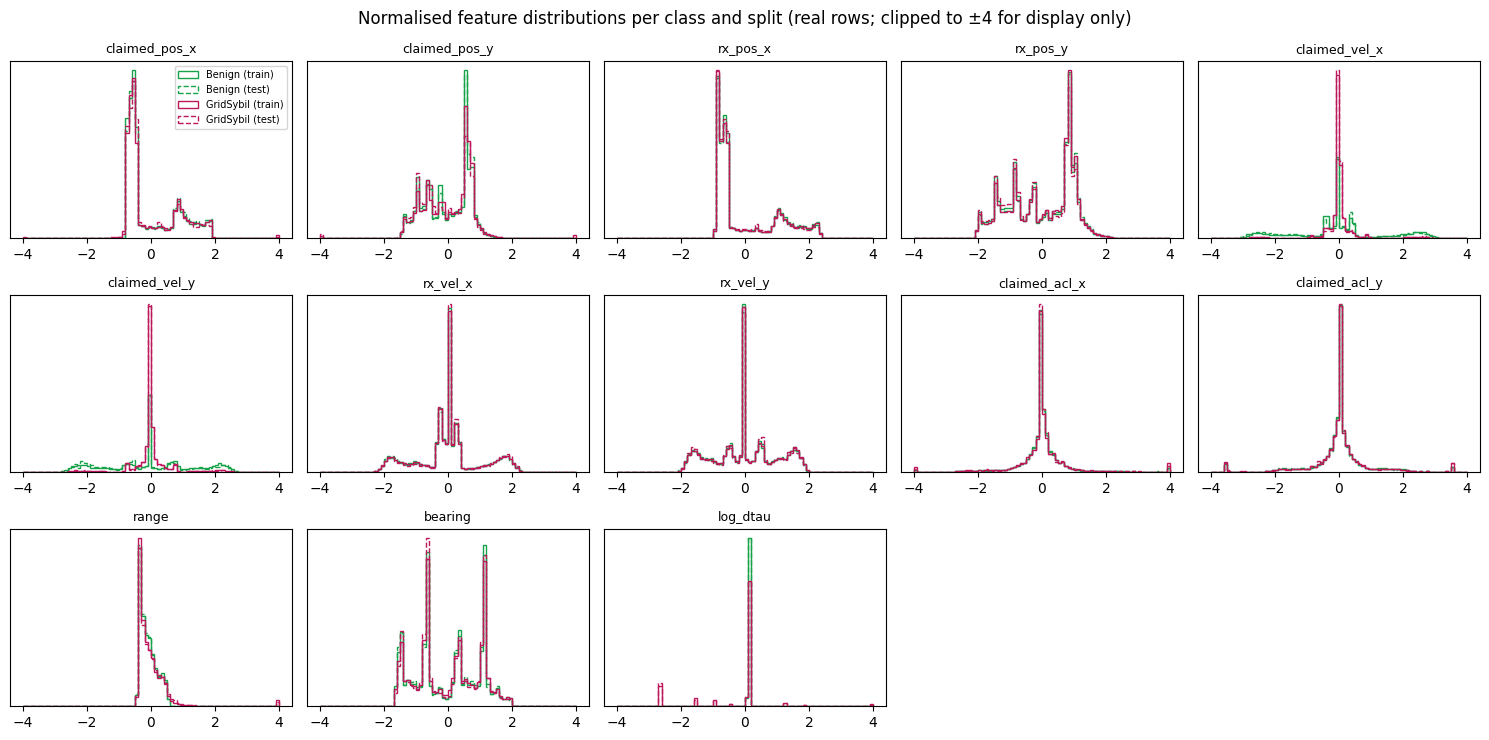

In [10]:
fig, axes = plt.subplots(3, 5, figsize=(15, 7.5))
rows_by = {(c, s): features.real_rows(c, s) for c in COLOURS for s in SPLITS}
bins = np.linspace(-4, 4, 81)
for j, ax in enumerate(axes.flat):
    if j >= len(FEATURES):
        ax.axis("off")
        continue
    for (name, split), rows in rows_by.items():
        ax.hist(
            np.clip(rows[:, j], -4, 4),
            bins=bins,
            density=True,
            histtype="step",
            color=COLOURS[name],
            ls=SPLIT_STYLE[split],
            label=f"{name} ({split})",
        )
    ax.set_title(FEATURES[j], fontsize=9)
    ax.set_yticks([])
axes.flat[0].legend(fontsize=7)
fig.suptitle("Normalised feature distributions per class and split (real rows; clipped to ±4 for display only)")
plt.tight_layout()
plt.show()

## Does the train normalisation hold in the other splits?

On train real rows every feature should have mean ≈ 0 and std ≈ 1 (that is how it was fitted). Test should be close; a
large shift would mean the splits differ in a way the model has to cope with.

In [11]:
norm_rows = []
real_by_split = {s: features.real_rows(split=s) for s in SPLITS}
for split, r in real_by_split.items():
    for j, f in enumerate(FEATURES):
        norm_rows.append({"split": split, "feature": f, "mean": r[:, j].mean(), "std": r[:, j].std()})
norm = (
    pd.DataFrame(norm_rows)
    .pivot(index="feature", columns="split", values=["mean", "std"])
    .reindex(FEATURES)
    .reindex(columns=SPLITS, level=1)
    .round(3)
)
print(norm.to_string())
train_dev = max(norm["mean"][FIT].abs().max(), (norm["std"][FIT] - 1).abs().max())
shift = norm["mean"].sub(norm["mean"][FIT], axis=0).abs().drop(columns=FIT).max().max()
print(
    f"Observation: on {FIT} the largest |mean| or |std − 1| is {train_dev:.3f}; the largest mean shift from {FIT} in "
    f"another split is {shift:.3f} standard deviations."
)

               mean           std       
split         train   test  train   test
feature                                 
claimed_pos_x   0.0 -0.015  1.000  0.862
claimed_pos_y  -0.0 -0.080  1.000  0.833
rx_pos_x       -0.0 -0.018  1.000  0.981
rx_pos_y        0.0 -0.061  1.000  1.006
claimed_vel_x  -0.0 -0.022  1.000  0.977
claimed_vel_y  -0.0 -0.081  1.000  0.965
rx_vel_x       -0.0  0.019  1.000  1.005
rx_vel_y       -0.0 -0.009  1.000  1.001
claimed_acl_x   0.0  0.000  1.000  0.915
claimed_acl_y   0.0  0.005  1.000  0.991
range           0.0 -0.014  1.000  0.605
bearing         0.0 -0.013  1.000  0.996
log_dtau        0.0 -0.036  0.974  1.015
Observation: on train the largest |mean| or |std − 1| is 0.026; the largest mean shift from train in another split is 0.081 standard deviations.


**Researcher note:** [RISK] The line reports only the mean shift (0.081); test std is 0.605 for range and 0.83–0.86 for claimed_pos because GridSybil outliers inflate the train std (benign range p01–p99 spans only −0.40 to 0.51 z).

## Train vs test shift per feature

Per feature on real rows: the difference in mean and in std between test and train, in train-std units (the features
are z-scores of train, so the numbers are already in those units), and the two-sample Kolmogorov–Smirnov statistic (the
largest gap between the two cumulative distributions; 0 = identical). The KS statistic uses a random sample of 500,000
real rows per split (seed 0). With samples this large every p-value is tiny, so only the size of the statistic is
read: below about 0.05 is a small shift.

In [12]:
rng = np.random.default_rng(0)
_tr, _ev = real_by_split[FIT], real_by_split[EVAL]
_tr_s = _tr[rng.choice(len(_tr), size=min(500_000, len(_tr)), replace=False)]
_ev_s = _ev[rng.choice(len(_ev), size=min(500_000, len(_ev)), replace=False)]
shift_rows = []
for j, f in enumerate(FEATURES):
    shift_rows.append(
        {
            "feature": f,
            "mean_diff_train_std": _ev[:, j].mean() - _tr[:, j].mean(),
            "std_diff_train_std": _ev[:, j].std() - _tr[:, j].std(),
            "ks": ks_2samp(_tr_s[:, j], _ev_s[:, j]).statistic,
        }
    )
shift_tab = pd.DataFrame(shift_rows).set_index("feature").sort_values("ks", ascending=False).round(4)
print(shift_tab.to_string())
cls_ks = {}
for c in COLOURS:
    a, b = rows_by[(c, FIT)], rows_by[(c, EVAL)]
    a = a[rng.choice(len(a), size=min(300_000, len(a)), replace=False)]
    b = b[rng.choice(len(b), size=min(300_000, len(b)), replace=False)]
    ks_c = pd.Series({f: ks_2samp(a[:, j], b[:, j]).statistic for j, f in enumerate(FEATURES)})
    cls_ks[c] = (ks_c.idxmax(), ks_c.max())
print(
    f"Observation: largest {FIT}→{EVAL} KS = {shift_tab['ks'].iloc[0]:.3f} ({shift_tab.index[0]}), median KS over "
    f"features {shift_tab['ks'].median():.3f}; largest |mean diff| {shift_tab['mean_diff_train_std'].abs().max():.3f} "
    f"and |std diff| {shift_tab['std_diff_train_std'].abs().max():.3f} train std; within class the largest KS is "
    + "; ".join(f"{c} {v:.3f} ({f})" for c, (f, v) in cls_ks.items())
    + "."
)

               mean_diff_train_std  std_diff_train_std      ks
feature                                                       
claimed_pos_y              -0.0796             -0.1674  0.0421
claimed_vel_y              -0.0807             -0.0352  0.0338
rx_pos_y                   -0.0612              0.0060  0.0317
claimed_vel_x              -0.0215             -0.0227  0.0264
rx_vel_x                    0.0194              0.0049  0.0182
claimed_pos_x              -0.0149             -0.1378  0.0181
log_dtau                   -0.0359              0.0406  0.0157
range                      -0.0139             -0.3953  0.0154
bearing                    -0.0131             -0.0038  0.0144
claimed_acl_x               0.0002             -0.0854  0.0142
rx_pos_x                   -0.0185             -0.0189  0.0121
claimed_acl_y               0.0052             -0.0085  0.0068
rx_vel_y                   -0.0090              0.0009  0.0064


Observation: largest train→test KS = 0.042 (claimed_pos_y), median KS over features 0.016; largest |mean diff| 0.081 and |std diff| 0.395 train std; within class the largest KS is Benign 0.078 (claimed_vel_y); GridSybil 0.080 (claimed_pos_y).


**Researcher note:** [RIGHT] KS ≤ 0.042 overall and ≤ 0.080 within class: no meaningful covariate shift; the 0.395 std gap is the range tail from the previous two notes, so test is a fair held-out set.

## How the features move together

Correlation between features over a sample of real rows, for train (plot) and for every split (largest difference
between splits). Strong pairs carry partly the same information (for example the receiver's own position and the
claimed position of nearby honest senders).

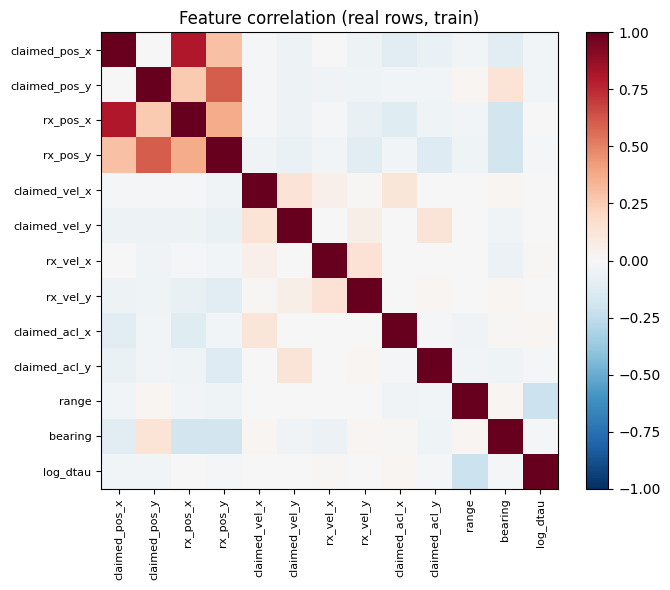

Observation: strongest pairs on train: claimed_pos_x ~ rx_pos_x (+0.80); claimed_pos_y ~ rx_pos_y (+0.61); rx_pos_x ~ rx_pos_y (+0.37); claimed_pos_x ~ rx_pos_y (+0.29); claimed_pos_y ~ rx_pos_x (+0.26); largest correlation difference between train and another split = 0.363 (range ~ claimed_pos_y: train +0.02).


In [13]:
rng = np.random.default_rng(0)
corr_by = {}
for s, r in real_by_split.items():
    sample = r[rng.choice(len(r), size=min(200_000, len(r)), replace=False)]
    corr_by[s] = np.corrcoef(sample.T)
corr = corr_by[FIT]
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=90, fontsize=8)
ax.set_yticks(range(len(FEATURES)), FEATURES, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title(f"Feature correlation (real rows, {FIT})")
plt.tight_layout()
plt.show()
pairs = [(FEATURES[i], FEATURES[j], corr[i, j]) for i in range(len(FEATURES)) for j in range(i + 1, len(FEATURES))]
top = sorted(pairs, key=lambda t: -abs(t[2]))[:5]
_diff = max((np.abs(corr_by[s] - corr) for s in SPLITS if s != FIT), key=lambda d: d.max())
_i, _j = np.unravel_index(np.argmax(_diff), _diff.shape)
corr_diff = _diff[_i, _j]
print(
    f"Observation: strongest pairs on {FIT}: "
    + "; ".join(f"{a} ~ {b} ({c:+.2f})" for a, b, c in top)
    + f"; largest correlation difference between {FIT} and another split = {corr_diff:.3f} "
    f"({FEATURES[_i]} ~ {FEATURES[_j]}: {FIT} {corr[_i, _j]:+.2f})."
)

**Researcher note:** [RISK] The 0.363 change in range ~ claimed_pos_y (train +0.02) is probably Pearson driven by the GridSybil tail; recompute with Spearman before reading it as shift. claimed ~ rx position +0.80 is expected (range is short).

## Which single features separate benign from GridSybil?

For each feature, the window average over real rows is the only input of a logistic regression **fitted on train**;
its AUC between benign and GridSybil is measured **on test**. Train fixes the direction, so an AUC below 0.5 means the
direction learnt on train flips on test. AUC 0.5 = no separation; the further from 0.5, the more that feature alone
tells the classes apart. This is a rough look, not a result.

In [14]:
class SingleFeatureSeparation:
    """Test AUC of each feature's per-window mean (real rows only), one logistic regression per feature fit on train."""

    def __init__(self, x_by: dict[int, np.ndarray], m_by: dict[int, np.ndarray], table: pd.DataFrame) -> None:
        self.x_by, self.m_by, self.table = x_by, m_by, table

    def table_auc(self, fit: str = FIT, evaluate: str = EVAL) -> pd.Series:
        """AUC per feature on `evaluate`, sorted by distance from 0.5."""
        _, m_tr, y_tr = window_means(self.x_by, self.m_by, self.table, fit)
        _, m_ev, y_ev = window_means(self.x_by, self.m_by, self.table, evaluate)
        auc = pd.Series({f: fitted_auc(m_tr[:, j], y_tr, m_ev[:, j], y_ev) for j, f in enumerate(FEATURES)})
        return auc.reindex((auc - 0.5).abs().sort_values(ascending=False).index).round(3)


separation = SingleFeatureSeparation(X, MASK, info).table_auc()
print(separation.to_string())
best = separation.index[0]
print(
    f"Observation: the strongest single feature is {best} (fit on {FIT}, test AUC {separation.iloc[0]:.3f}); "
    f"{int(((separation - 0.5).abs() > 0.1).sum())} of 13 features reach |AUC − 0.5| > 0.1 on their own; "
    f"{int((separation < 0.5).sum())} features have a test AUC below 0.5."
)

claimed_vel_y    0.446
claimed_pos_y    0.456
claimed_vel_x    0.465
rx_pos_y         0.465
range            0.513
claimed_acl_x    0.512
rx_vel_y         0.512
rx_pos_x         0.490
bearing          0.492
rx_vel_x         0.493
log_dtau         0.507
claimed_acl_y    0.504
claimed_pos_x    0.496
Observation: the strongest single feature is claimed_vel_y (fit on train, test AUC 0.446); 0 of 13 features reach |AUC − 0.5| > 0.1 on their own; 8 features have a test AUC below 0.5.


**Researcher note:** [WRONG] Calling claimed_vel_y 'strongest' misleads: its test AUC 0.446 means the train-fitted direction reverses on test, as for 8 of 13 features; per-message cues do not transfer (best in the train direction: range 0.513).

## Repeated broadcasts and duplicate copies

One broadcast is heard by several cars, so the **claimed** columns (what the sender says) of a window can be identical
in another receiver's window. This counts windows whose first real message carries exactly the same claimed values
(position and velocity, normalised, rounded to 4 decimals) as some other window — correlated samples. They should
stay in one split, because the split is by sender vehicle; a group that crosses train / test is checked for being a
standing car (claimed speed < 0.1 m/s), i.e. different vehicles that happen to report the same values rather than a
copy of one broadcast.

In [15]:
claimed_cols = [FEATURES.index(c) for c in ("claimed_pos_x", "claimed_pos_y", "claimed_vel_x", "claimed_vel_y")]
keys = []
for b, x in X.items():
    sel = info[info["bucket"] == b]
    first = x[sel["row"].to_numpy(), 0][:, claimed_cols]
    keys.append(
        pd.DataFrame(
            {
                "key": [tuple(r) for r in np.round(first, 4)],
                "label": sel["label_name"].to_numpy(),
                "split": sel["split"].to_numpy(),
                "vehicle": sel["vehicle"].to_numpy(),
            }
        )
    )
keys = pd.concat(keys, ignore_index=True)
keys["repeated"] = keys.duplicated("key", keep=False)
print(keys.groupby(["split", "label"])["repeated"].mean().reindex(SPLITS, level=0).round(3).to_string())
groups = keys[keys["repeated"]].groupby("key")
same_split = groups["split"].nunique().eq(1).mean()
norm_stats = META["normalisation"]
vel_mean = np.array([norm_stats["mean"][FEATURES.index(c)] for c in ("claimed_vel_x", "claimed_vel_y")])
vel_std = np.array([norm_stats["std"][FEATURES.index(c)] for c in ("claimed_vel_x", "claimed_vel_y")])
cross = groups["split"].nunique().loc[lambda s: s > 1].index
cross_speed = np.array([np.hypot(*(np.array(k[2:]) * vel_std + vel_mean)) for k in cross])
moving_cross = int((cross_speed >= 0.1).sum())
cross_windows = keys[keys["key"].isin(set(cross))]
rep_split = keys.groupby("split")["repeated"].mean().reindex(SPLITS)
print(
    f"groups crossing splits: {len(cross)}; windows in them per split: "
    f"{cross_windows.groupby('split').size().reindex(SPLITS).fillna(0).astype(int).to_dict()}; moving: {moving_cross}"
)
print(
    "Observation: windows sharing their first claimed message with another window: "
    + " / ".join(f"{s} {rep_split[s]:.1%}" for s in SPLITS)
    + f"; {same_split:.1%} of the groups stay inside one split; {len(cross)} groups cross splits, "
    f"{(np.mean(cross_speed < 0.1) if len(cross) else float('nan')):.1%} of them standing cars "
    f"(claimed speed < 0.1 m/s), {moving_cross} moving."
)

split  label    
train  Benign       0.525
       GridSybil    0.584
test   Benign       0.518
       GridSybil    0.589
groups crossing splits: 314; windows in them per split: {'train': 1103, 'test': 571}; moving: 0
Observation: windows sharing their first claimed message with another window: train 56.3% / test 56.5%; 99.5% of the groups stay inside one split; 314 groups cross splits, 100.0% of them standing cars (claimed speed < 0.1 m/s), 0 moving.


**Researcher note:** [BETTER] 56% of windows share a broadcast with another window and train.py only counts same-link pairs (diagnostic); mask same-broadcast and same-link pairs as NT-Xent false negatives. The 314 cross-split groups are all standing cars, so no leak.

## Check-set preview (pretraining's 10% hold-out)

Pretraining carves a label-free check set out of train: 10% of the train sender vehicles, chosen by the same rule as
`FeatureShards.hold_out` in `src/model/benign_gridsybil/timesnet/data.py` (sorted vehicle keys, shuffled with
`numpy.random.default_rng(seed)`, the first `round(frac × n)` taken). The fraction and seed are read from
`PretrainConfig`. Labels are used here only to describe the result; pretraining never sees them.

In [16]:
_spec = importlib.util.spec_from_file_location("pretrain_config", "src/model/benign_gridsybil/timesnet/config.py")
_cfg_mod = importlib.util.module_from_spec(_spec)
sys.modules["pretrain_config"] = _cfg_mod
_spec.loader.exec_module(_cfg_mod)
CFG = _cfg_mod.PretrainConfig()
train_info = info[info["split"] == FIT]
_veh = sorted(set(train_info["vehicle"]))
_rng = np.random.default_rng(CFG.seed)
_rng.shuffle(_veh)
chosen = set(_veh[: max(1, int(round(CFG.holdout_frac * len(_veh))))])
part = np.where(train_info["vehicle"].isin(chosen), "check", "rest")
preview = (
    train_info.assign(part=part)
    .groupby("part")
    .agg(
        windows=("id", "size"),
        vehicles=("vehicle", "nunique"),
        benign_share=("label_name", lambda s: s.eq("Benign").mean()),
        share_1_to_3=("n_messages", lambda n: (n <= 3).mean()),
        padding=("padding_rows", lambda p: p.sum() / (64 * len(p))),
    )
)
preview[f"{g0}_share"] = train_info.assign(part=part).groupby("part")["group"].apply(lambda g: g.eq(g0).mean())
print(f"holdout_frac = {CFG.holdout_frac}, seed = {CFG.seed}")
print(preview.round(3).to_string())
chk = preview.loc["check"]
print(
    f"Observation: the check set holds {int(chk['windows']):,} windows ({chk['windows'] / len(train_info):.1%} of "
    f"{FIT}) from {int(chk['vehicles']):,} vehicles; benign share {chk['benign_share']:.1%} vs "
    f"{preview.loc['rest', 'benign_share']:.1%} in the rest; {g0} share {chk[f'{g0}_share']:.1%} vs "
    f"{preview.loc['rest', f'{g0}_share']:.1%}; 1–3-message windows {chk['share_1_to_3']:.1%} vs "
    f"{preview.loc['rest', 'share_1_to_3']:.1%}."
)

holdout_frac = 0.1, seed = 0
       windows  vehicles  benign_share  share_1_to_3  padding  0709_share
part                                                                     
check    33268       518         0.369         0.182    0.709       0.791
rest    304733      4660         0.354         0.180    0.711       0.809
Observation: the check set holds 33,268 windows (9.8% of train) from 518 vehicles; benign share 36.9% vs 35.4% in the rest; 0709 share 79.1% vs 80.9%; 1–3-message windows 18.2% vs 18.0%.


**Researcher note:** [RIGHT] 33,268 windows (9.8% of train) from 518 vehicles, matching the rest within 1.8 pp on benign share, 0709 share and short windows: a sound vehicle-disjoint, label-free set for D7 checkpoint selection.

## Summary

The numbers above, in one place. They describe the input; they are not model results.

In [17]:
summary = {
    "windows per split": ", ".join(f"{s} {int((info['split'] == s).sum()):,}" for s in SPLITS),
    "sender vehicles per split (overlap)": ", ".join(f"{s} {len(vehicles[s]):,}" for s in SPLITS)
    + f" ({sum(overlap.values())})",
    "benign share per split": ", ".join(f"{s} {benign_share[s]:.1%}" for s in SPLITS),
    "window shape": "64 × 13 (+ 64-value mask)",
    "padding overall": f"{overall_pad:.1%}",
    "1–3-message windows (benign / GridSybil, all splits)": " / ".join(
        f"{(info.loc[info['label_name'] == c, 'n_messages'] <= 3).mean():.1%}" for c in COLOURS
    ),
    f"length-only probe AUC ({FIT} → {EVAL})": round(auc_len, 3),
    f"best single-feature AUC, masked vs plain mean ({FIT} → {EVAL})": f"{best_masked:.3f} vs {best_plain:.3f}",
    f"strongest single feature ({FIT} → {EVAL} AUC)": f"{best} ({separation.iloc[0]:.3f})",
    "largest mean shift vs train (std units)": round(float(shift), 3),
    f"largest KS {FIT} vs {EVAL}": f"{shift_tab['ks'].iloc[0]:.3f} ({shift_tab.index[0]})",
    f"largest {g0}-share gap between splits (pp)": round(float(gap) * 100, 1),
    "GridSybil windows with pseudonym 1": ", ".join(f"{s} {ghost.loc[(s, 'GridSybil'), 'mean']:.1%}" for s in SPLITS),
    "windows sharing a first claimed message": ", ".join(f"{s} {rep_split[s]:.1%}" for s in SPLITS),
    "groups crossing splits (moving)": f"{len(cross)} ({moving_cross})",
    "check set (windows / vehicles / benign share)": (
        f"{int(chk['windows']):,} / {int(chk['vehicles']):,} / {chk['benign_share']:.1%}"
    ),
}
pd.Series(summary, name="value").to_frame()

,value
windows per split,"train 338,001, test 38,426"
sender vehicles per split (overlap),"train 5,178, test 574 (0)"
benign share per split,"train 35.5%, test 33.2%"
window shape,64 × 13 (+ 64-value mask)
padding overall,71.0%
"1–3-message windows (benign / GridSybil, all splits)",13.9% / 20.2%
length-only probe AUC (train → test),0.535
"best single-feature AUC, masked vs plain mean (train → test)",0.554 vs 0.562
strongest single feature (train → test AUC),claimed_vel_y (0.446)
largest mean shift vs train (std units),0.081


## Researcher verdicts

One verdict per observation, judged against the numbers above and the adopted plan. RIGHT = supports the current direction; RISK = could mislead the model or the thesis; WRONG = the current reading or approach is not right; BETTER = a concrete better way. Counts: RIGHT 4, RISK 6, WRONG 1, BETTER 2.

| # | Observation | Verdict | Comment |
|---|---|---|---|
| 1 | Counts and padding | RISK | Vehicle-disjoint (0 overlap), but there is no labelled validation split: probes and Stage 2 K, θ need a vehicle-grouped carve from train; also reconcile 5,178 / 574 with the 5,180 / 575 in the split manifest. |
| 2 | Class balance and length per split | RISK | Balance is stable (benign 35.5% vs 33.2%), but 1–3-message windows (benign 14%, GridSybil 19–20%) are below min_rows_aux = 4, so they get reconstruction only; report probes per length band. |
| 3 | Scenario-group mix per split | RISK | Mix matches within 3.9 pp, but 1416 test is only 6,591 windows (2,433 benign / 4,158 GridSybil); 0709 ↔ 1416 transfer numbers need vehicle-level bootstrap CIs. |
| 4 | Ghost pseudonym 1 (F13) | RISK | 20.4% / 21.5% of GridSybil windows carry pseudonym 1, from 1,504 of 1,553 train GridSybil vehicles; exclude pseudonym 1 from D6's 'other pseudonym' rule and never use the true-sender key in pretraining. |
| 5 | Window length and the length shortcut | RIGHT | Length alone gives test AUC 0.535, a weak shortcut; report it next to every probe as the floor a learned encoder must clearly beat. |
| 6 | Padding and why the mask matters | RIGHT | An unmasked mean leaks length (log_dtau 0.507 → 0.562), so masked pooling and train.py's preflight padding-invariance check are needed (not yet run); 0.554 is 0.5 + distance, the raw masked AUC is 0.446. |
| 7 | Feature values per class and split | BETTER | |z| > 10 occurs only in GridSybil claimed_pos / range (train 0.16–0.39%, test ≤ 0.03%, max z 30); clip or use median/IQR train scaling for these features, or a Huber reconstruction loss. |
| 8 | Does the train normalisation hold in the other splits? | RISK | The line reports only the mean shift (0.081); test std is 0.605 for range and 0.83–0.86 for claimed_pos because GridSybil outliers inflate the train std (benign range p01–p99 spans only −0.40 to 0.51 z). |
| 9 | Train vs test shift per feature | RIGHT | KS ≤ 0.042 overall and ≤ 0.080 within class: no meaningful covariate shift; the 0.395 std gap is the range tail from the previous two notes, so test is a fair held-out set. |
| 10 | How the features move together | RISK | The 0.363 change in range ~ claimed_pos_y (train +0.02) is probably Pearson driven by the GridSybil tail; recompute with Spearman before reading it as shift. claimed ~ rx position +0.80 is expected (range is short). |
| 11 | Which single features separate benign from GridSybil? | WRONG | Calling claimed_vel_y 'strongest' misleads: its test AUC 0.446 means the train-fitted direction reverses on test, as for 8 of 13 features; per-message cues do not transfer (best in the train direction: range 0.513). |
| 12 | Repeated broadcasts and duplicate copies | BETTER | 56% of windows share a broadcast with another window and train.py only counts same-link pairs (diagnostic); mask same-broadcast and same-link pairs as NT-Xent false negatives. The 314 cross-split groups are all standing cars, so no leak. |
| 13 | Check-set preview (pretraining's 10% hold-out) | RIGHT | 33,268 windows (9.8% of train) from 518 vehicles, matching the rest within 1.8 pp on benign share, 0709 share and short windows: a sound vehicle-disjoint, label-free set for D7 checkpoint selection. |

## Top 3 things to change before training

1. **Robust scaling for claimed_pos and range.** Clip at a train quantile or scale by median/IQR from train real rows (or use a Huber reconstruction loss), so a 0.4% GridSybil tail (max z 30) stops inflating the train std (test range std 0.605) and dominating the reconstruction loss.
2. **Remove contrastive false negatives.** Windows that share a broadcast (56% of windows) or a link are currently only counted (`same_link_pairs`); mask them in NT-Xent, and keep pseudonym 1 out of D6's hard-negative rule (F13).
3. **Fix the evaluation protocol before any probe.** Carve a vehicle-grouped labelled validation set from train for probes and K, θ; report AUC with vehicle-level bootstrap CIs (1416 test has 6,591 windows) and per length band (1–3-message windows get reconstruction only), next to the 0.535 length-only floor.

**Status (2026-10-08):** the two "before training" items are done in the pretraining code (decision D13). Robust scaling: `claimed_pos_x/y` and `range` use median / IQR of train real rows plus a soft tail beyond |z| = 5 (range 388 m → 1.00 instead of 0.65; the 12.8 km ghost → 8.8 instead of 36.4). Contrastive false negatives: windows of the same pseudonym in the same run are never negatives. This notebook still shows the stored train z-scores. Open before evaluation: labelled vehicle-grouped validation set, vehicle bootstrap CIs, results per length band.